In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Cinética de Procesos (Sesión 05)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 6. Modelos de dos parámetros

## 6.1 CSTR con derivación y zona muerta

### 6.1.1 Esquematización

<center>

<img src="figures/images/cstr_bypass_dead.png" style="width:400px" title="CSTR">

***Figura 01. Modelo de un CSTR con derivación y zona muerta.*** 


</center>

**El modelo de reactor CSTR con derivación y zona muerta, es un modelo en régimen estacionario, que consta de los siguiente componentes:**

**Unión 1:**

- El flujo volumétrico de entrada, $\dot{Q}_0$, se descompone en el flujo efectivo en el reactor, $\dot{Q}_s$, y el flujo en la derivación $\dot{Q}_b$.

$$\dot{Q}_0 = \dot{Q}_s + \dot{Q}_b$$

- La concentración es igual a la concentración inicial, $C_{\mathrm{A}}^0$.

**Reactor:**

- El volumen total del reactor, $V$, se descompone en el volumen efectivo de reacción, $V_S$, y el volumen de la zona muerta $V_d$.
$$V = V_s + V_d$$

- En el volumen efectivo de reacción, $V_S$, la cinética ocurre de acuerdo con la ecuación de diseño de un CSTR ideal.

    - El tiempo espacial del reactor se calcula a partir del volumen y del flujo efectivos, $\tau_s = V_s / \dot{Q}_s$.

    - La concentración a la salida del reactor, se denota mediante la variable $C_{\mathrm{A}}^S$.


$$\dot{Q}_s C_{\mathrm{A}}^0 - \dot{Q}_s  C_{\mathrm{A}}^s + r_{\mathrm{A}} V_{s} = 0$$

$$C_{\mathrm{A}}^0 - C_{\mathrm{A}}^s + r_{\mathrm{A}} \tau_{s} = 0$$

- En el volumen de la zona muerta, $V_d$, no ocurre ninguna reacción.





**Unión 2:**

- El flujo volumétrico a la salida, $\dot{Q_0}$, está constituido por el efluente del reactor, $\dot{Q_S}$ y el flujo en la derivación, $\dot{Q_b}$.

$$\dot{Q}_0 = \dot{Q}_s + \dot{Q}_b$$

- La concentración a la salida del reactor se calcula a partir del balance de materia en la unión:


$$\underbrace{C_{\mathrm{A}}^0 \dot{Q}_b + C_{\mathrm{A}}^S \dot{Q}_S}_{\text{entradas}} = \underbrace{C_{\mathrm{A}} \dot{Q}_0}_{\text{salidas}}$$

$$C_{\mathrm{A}} = \frac{C_{\mathrm{A}}^0 \dot{Q}_b + C_{\mathrm{A}}^S \dot{Q}_S}{\dot{Q}_0}$$

### 6.1.2 Parametrización

Este modelo consta de dos parámetros ajustables:

- La fracción de volumen efectivo del reactor
$$\alpha = \frac{V_s}{V}$$

- La fracción del flujo volumétrico que pasa por la derivación

$$\beta = \frac{\dot{Q}_b}{\dot{Q}_0}$$

La concentración a la salida del reactor se puede reescribir en términos de $\beta$:

$$C_{\mathrm{A}} = \frac{C_{\mathrm{A}}^0 \dot{Q}_b + C_{\mathrm{A}}^S \dot{Q}_S}{\dot{Q}_0}$$

$$C_{\mathrm{A}} = \beta C_{\mathrm{A}}^0 + \left(1 - \beta \right) C_{\mathrm{A}}^s$$

In [57]:
### modelo de reactor
alpha, beta = 0.2, 0.1
V = 15 # m3
Q0 = 1 # m3/min

Vs, Vd = alpha*V, (1-alpha)*V
Qs, Qb = (1-beta)*Q0, beta*Q0

taus = Vs/Qs


cA0 = 1
k = 0.307 # 1/min
r_A = lambda cA: -k*cA
def cstrOptFun(cA, cA0, tau):
    return    cA0 - cA + tau*r_A(cA)
cAs = fsolve(cstrOptFun, x0=cA0, args=(cA0, taus))[0]
cA = beta*cA0 + (1-beta)*cAs


print(f"CSTR with bypass and dead-zone")
print(f"alpha = {alpha:8.2f}")
print(f"beta  = {beta :8.2f}")
print(f"cA0   = {cA0:8.2f}")
print(f"cAs   = {cAs:8.2f}")
print(f"cA    = {cA:8.2f}")
print(f"xA    = {(1-cA/cA0):8.2f}")


CSTR with bypass and dead-zone
alpha =     0.20
beta  =     0.10
cA0   =     1.00
cAs   =     0.49
cA    =     0.54
xA    =     0.46


In [64]:
### modelo de reactor
alpha, beta = 0.0, 0.1
V = 15 # m3
Q0 = 1 # m3/min

Vs, Vd = alpha*V, (1-alpha)*V
Qs, Qb = (1-beta)*Q0, beta*Q0

taus = Vs/Qs


cA0 = 1
k = 0.307 # 1/min
r_A = lambda cA: -k*cA
def cstrOptFun(cA, cA0, tau):
    return    cA0 - cA + tau*r_A(cA)
cAs = fsolve(cstrOptFun, x0=cA0, args=(cA0, taus))[0]
cA = beta*cA0 + (1-beta)*cAs


print(f"CSTR with bypass and dead-zone")
print(f"alpha = {alpha:8.2f}")
print(f"beta  = {beta :8.2f}")
print(f"cA0   = {cA0:8.2f}")
print(f"cAs   = {cAs:8.2f}")
print(f"cA    = {cA:8.2f}")
print(f"xA    = {(1-cA/cA0):8.2f}")

CSTR with bypass and dead-zone
alpha =     0.00
beta  =     0.10
cA0   =     1.00
cAs   =     1.00
cA    =     1.00
xA    =     0.00


In [ ]:
alphas = np.linspace(0, 1, 11)


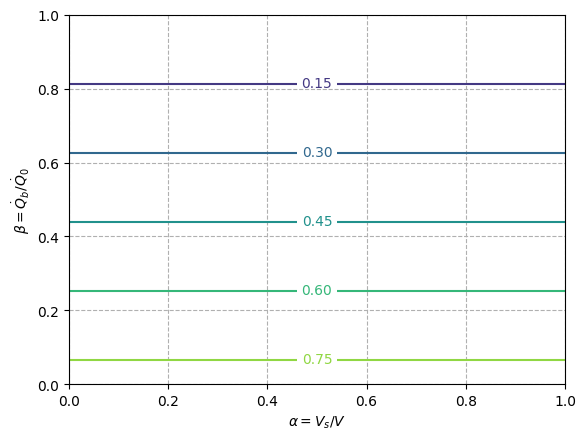

In [62]:
alphas = np.linspace(0, 1, 11)
betas = np.linspace(0, 1, 11)



V = 1 # m3
Q0 = 1 # m3/min
cA0 = 1
k = 0.307 # 1/min
r_A = lambda cA: -k*cA
def cstrOptFun(cA, cA0, tau):
    return    cA0 - cA + tau*r_A(cA)

data = []
for alpha in alphas:
    for beta in betas:
        Vs, Vd = alpha*V, (1-alpha)*V
        Qs, Qb = (1-beta)*Q0, beta*Q0
        cAs = fsolve(cstrOptFun, x0=cA0, args=(cA0, taus))[0]
        cA = beta*cA0 + (1-beta)*cAs
        data.append([alpha, beta, 1-cA/cA0])
data = np.array(data)

fig, ax = plt.subplots()
cs = ax.tricontour(data[:,0], data[:,1], data[:, 2])
ax.clabel(cs)
ax.set_xlabel(r"$\alpha = {V_s}/{V}$")
ax.set_ylabel(r"$\beta = {\dot{Q}_b}/{\dot{Q}_0}$")
ax.grid(ls='--')
plt.show()

In [63]:
data

array([[0.        , 0.        , 0.80366492],
       [0.        , 0.1       , 0.72329843],
       [0.        , 0.2       , 0.64293194],
       [0.        , 0.3       , 0.56256545],
       [0.        , 0.4       , 0.48219895],
       [0.        , 0.5       , 0.40183246],
       [0.        , 0.6       , 0.32146597],
       [0.        , 0.7       , 0.24109948],
       [0.        , 0.8       , 0.16073298],
       [0.        , 0.9       , 0.08036649],
       [0.        , 1.        , 0.        ],
       [0.1       , 0.        , 0.80366492],
       [0.1       , 0.1       , 0.72329843],
       [0.1       , 0.2       , 0.64293194],
       [0.1       , 0.3       , 0.56256545],
       [0.1       , 0.4       , 0.48219895],
       [0.1       , 0.5       , 0.40183246],
       [0.1       , 0.6       , 0.32146597],
       [0.1       , 0.7       , 0.24109948],
       [0.1       , 0.8       , 0.16073298],
       [0.1       , 0.9       , 0.08036649],
       [0.1       , 1.        , 0.        ],
       [0.